<div data-kag-design="1" style="background:rgba(194,151,74,.09);border-left:4px solid #c2974a;border-radius:10px;padding:22px 26px;font-family:'Segoe UI',Helvetica,Arial,sans-serif;">
  <div style="font-size:.74rem;font-weight:700;letter-spacing:.16em;color:#c2974a;text-transform:uppercase;">Exploratory Data Analysis · 2,022-Row Card Table</div>
  <h1 style="margin:8px 0 0;font-size:1.9rem;font-weight:800;color:inherit;letter-spacing:-.01em;">📊 🔍 Pokémon TCG Power Creep &amp; Damage</h1>
  <div style="height:4px;width:120px;background:#c2974a;border-radius:3px;margin:12px 0 14px;"></div>
  <p style="margin:0;font-size:1.02rem;line-height:1.55;color:inherit;opacity:.72;max-width:760px;">Cleaning the Pokémon TCG AI Battle Challenge sheet to trace expansion-era power creep and train a leakage-safe Damage regression baseline.</p>
</div>

<div style="background:rgba(194,151,74,.12);border:1px solid rgba(194,151,74,.30);border-left:6px solid #c2974a;border-radius:11px;padding:20px 26px;font-family:'Segoe UI',Helvetica,Arial,sans-serif;">
  <div style="font-size:1.12rem;font-weight:800;color:inherit;margin-bottom:12px;">🧭&nbsp;&nbsp;Table of Contents</div>
  <div style="display:flex;flex-wrap:wrap;gap:0 48px;">
    <div style="flex:1;min-width:240px;">
<a href="#sec-setup" style="color:inherit;text-decoration:none;display:block;padding:5px 0;font-size:.96rem;"><span style="color:#c2974a;font-weight:700;">01</span>&nbsp;&nbsp;⚙️&nbsp;&nbsp;Setup</a>
<a href="#sec-data-loading-schema" style="color:inherit;text-decoration:none;display:block;padding:5px 0;font-size:.96rem;"><span style="color:#c2974a;font-weight:700;">02</span>&nbsp;&nbsp;📂&nbsp;&nbsp;Data Loading &amp; Schema</a>
<a href="#sec-row-grain-investigation" style="color:inherit;text-decoration:none;display:block;padding:5px 0;font-size:.96rem;"><span style="color:#c2974a;font-weight:700;">03</span>&nbsp;&nbsp;🔬&nbsp;&nbsp;Row-Grain Investigation</a>
<a href="#sec-data-quality-sentinels-localization" style="color:inherit;text-decoration:none;display:block;padding:5px 0;font-size:.96rem;"><span style="color:#c2974a;font-weight:700;">04</span>&nbsp;&nbsp;🌐&nbsp;&nbsp;Data Quality, Sentinels &amp; Localization</a>
<a href="#sec-card-composition-breakdown" style="color:inherit;text-decoration:none;display:block;padding:5px 0;font-size:.96rem;"><span style="color:#c2974a;font-weight:700;">05</span>&nbsp;&nbsp;🃏&nbsp;&nbsp;Card Composition Breakdown</a>
<a href="#sec-numeric-feature-engineering" style="color:inherit;text-decoration:none;display:block;padding:5px 0;font-size:.96rem;"><span style="color:#c2974a;font-weight:700;">06</span>&nbsp;&nbsp;🧮&nbsp;&nbsp;Numeric Feature Engineering</a>
<a href="#sec-move-effect-text-mining" style="color:inherit;text-decoration:none;display:block;padding:5px 0;font-size:.96rem;"><span style="color:#c2974a;font-weight:700;">07</span>&nbsp;&nbsp;📜&nbsp;&nbsp;Move &amp; Effect Text Mining</a>
    </div>
    <div style="flex:1;min-width:240px;">
<a href="#sec-expansion-timeline-power-creep" style="color:inherit;text-decoration:none;display:block;padding:5px 0;font-size:.96rem;"><span style="color:#c2974a;font-weight:700;">08</span>&nbsp;&nbsp;📈&nbsp;&nbsp;Expansion Timeline - Power Creep</a>
<a href="#sec-sub-pool-profiling-ace-spec-tool-sta" style="color:inherit;text-decoration:none;display:block;padding:5px 0;font-size:.96rem;"><span style="color:#c2974a;font-weight:700;">09</span>&nbsp;&nbsp;🏟️&nbsp;&nbsp;Sub-Pool Profiling: ACE SPEC, Tool, Stadium, Special Energy</a>
<a href="#sec-type-synergy-graph" style="color:inherit;text-decoration:none;display:block;padding:5px 0;font-size:.96rem;"><span style="color:#c2974a;font-weight:700;">10</span>&nbsp;&nbsp;🕸️&nbsp;&nbsp;Type Synergy Graph</a>
<a href="#sec-mulligan-brick-risk-simulation" style="color:inherit;text-decoration:none;display:block;padding:5px 0;font-size:.96rem;"><span style="color:#c2974a;font-weight:700;">11</span>&nbsp;&nbsp;🎲&nbsp;&nbsp;Mulligan Brick-Risk Simulation</a>
<a href="#sec-modeling-predict-attack-damage" style="color:inherit;text-decoration:none;display:block;padding:5px 0;font-size:.96rem;"><span style="color:#c2974a;font-weight:700;">12</span>&nbsp;&nbsp;💥&nbsp;&nbsp;Modeling - Predict Attack Damage</a>
<a href="#sec-findings-agent-handoff" style="color:inherit;text-decoration:none;display:block;padding:5px 0;font-size:.96rem;"><span style="color:#c2974a;font-weight:700;">13</span>&nbsp;&nbsp;🤝&nbsp;&nbsp;Findings &amp; Agent Handoff</a>
    </div>
  </div>
</div>

A strategy-ready tour of the English Pokmon Trading Card Game card table that ships with the **Pokmon TCG AI Battle Challenge**. The notebook cleans the 2,022-row card sheet, surfaces meta-level patterns the community hasn't fully explored, and ends with a grouped-CV regression baseline for attack **Damage** that a downstream battle agent can consume.


**TL;DR**

- **Row grain is (card, move), not card.** 1,267 unique Card IDs spread across 2,022 rows - multi-attack cards repeat.
- **`n/a` strings, not nulls.** HP / Damage / Retreat / Cost use `"n/a"` sentinels; the only structural nulls (214 each in Weakness & Resistance) line up with non-Pokmon rows.
- **Power creep is real.** Mean HP, max Damage, and ex-share all drift upward across the 20 expansion codes.
- **Energy glyphs `{G}{R}{W}...` everywhere** - Cost is a multiset of these symbols and must be parsed before any modeling.
- **Tiny sub-pools matter.** ACE SPEC (29), Pokmon Tool (28), Stadium (26), and Special Energy (12) carry outsized strategic weight.
- **Champion model:** LightGBM regressor on parsed Cost + Type + Effect-text SVD features, validated with `GroupKFold(Card ID)` so attacks from the same card never leak across folds.

**What this notebook adds vs. the community**

Existing public notebooks on this dataset focus on either deck-building heuristics (nursrijan, lucifer19), full RL agent design (alycemiki), or quick category EDA (johnjanson). This one fills two gaps: an **expansion-timeline power-creep view** across all 20 set codes, and a **Damage-per-Energy regression baseline** with leakage-safe grouped cross-validation.

**Dataset:** [Pokmon TCG - AI Battle Challenge Strategy](https://www.kaggle.com/datasets/pokemon-tcg-ai-battle-challenge-strategy)

<a id="sec-setup"></a>
<div style="background:rgba(194,151,74,.11);border-left:4px solid #c2974a;border-radius:8px;padding:12px 18px;margin:10px 0;font-family:'Segoe UI',Helvetica,Arial,sans-serif;">
  <span style="font-size:1.16rem;font-weight:800;color:inherit;">⚙️&nbsp;&nbsp;Setup</span>
  <span style="color:#c2974a;opacity:.85;font-size:.76rem;font-weight:700;letter-spacing:.12em;float:right;padding-top:6px;">SECTION&nbsp;01</span>
</div>

In [1]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from tqdm.auto import tqdm

try:
    import missingno as msno
except ImportError:
    msno = None

warnings.filterwarnings("ignore")


In [2]:
# Named constants used across the notebook.
SEED = 42
MAX_SAMPLE_ROWS = 100_000
NUMERIC_BINS = 40
TOP_K_CATEGORIES = 20
WOW_FIG_HEIGHT = 520


In [3]:
# Fix all random seeds so results are reproducible.
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)


In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import seaborn as sns

# -- core palette ------------------------------------------------
# Hand-tuned 8-color palette: high contrast, color-blind safe, looks good on dark+light.
PALETTE: list[str] = [
    "#4C72B0",  # steel blue
    "#DD8452",  # warm orange
    "#55A868",  # forest green
    "#C44E52",  # brick red
    "#8172B3",  # muted purple
    "#937860",  # taupe
    "#DA8BC3",  # rose
    "#8C8C8C",  # neutral gray
]
ACCENT: str = "#E45756"   # for annotations / key callouts
GRID: str = "#E5E5E5"
TEXT: str = "#222222"

# -- matplotlib / seaborn defaults ------------------------------
mpl.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 110,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.edgecolor": TEXT,
    "axes.labelcolor": TEXT,
    "axes.prop_cycle": mpl.cycler(color=PALETTE),
    "axes.grid": True,
    "grid.color": GRID,
    "grid.alpha": 0.6,
    "xtick.color": TEXT,
    "ytick.color": TEXT,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "legend.frameon": False,
    "savefig.bbox": "tight",
})
sns.set_palette(PALETTE)
sns.set_style("whitegrid", {"grid.color": GRID})

# -- plotly template --------------------------------------------
_layout = go.Layout(
    colorway=PALETTE,
    font=dict(family="DejaVu Sans, Arial, sans-serif", color=TEXT, size=13),
    paper_bgcolor="white",
    plot_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor=GRID, zerolinecolor=GRID, linecolor=TEXT),
    yaxis=dict(showgrid=True, gridcolor=GRID, zerolinecolor=GRID, linecolor=TEXT),
    title=dict(font=dict(size=18, color=TEXT)),
    margin=dict(l=60, r=30, t=70, b=60),
    legend=dict(bgcolor="rgba(0,0,0,0)"),
)
pio.templates["kag_gm"] = go.layout.Template(layout=_layout)
pio.templates.default = "kag_gm"
pio.renderers.default = "plotly_mimetype+notebook_connected"


def annotate_peak(ax: plt.Axes, x: float, y: float, label: str) -> None:
    """Drop a one-line annotation arrow on a matplotlib Axes."""
    ax.annotate(
        label,
        xy=(x, y),
        xytext=(10, 10),
        textcoords="offset points",
        color=ACCENT,
        fontweight="bold",
        arrowprops=dict(arrowstyle="->", color=ACCENT, lw=1.2),
    )

class _PaletteShim(list):
    """List of hex colors that also supports dict-style semantic keys."""
    _KEYS = {
        "primary": 0, "accent": 1, "danger": 3, "success": 2,
        "warning": 1, "neutral": 7, "secondary": 4, "muted": 5,
    }
    def __getitem__(self, k):
        if isinstance(k, str):
            return list.__getitem__(self, self._KEYS[k])
        return list.__getitem__(self, k)

PALETTE = _PaletteShim(PALETTE)
KAG_PALETTE = PALETTE
KAG_COLORS = list(PALETTE)


<a id="sec-data-loading-schema"></a>
<div style="background:rgba(194,151,74,.11);border-left:4px solid #c2974a;border-radius:8px;padding:12px 18px;margin:10px 0;font-family:'Segoe UI',Helvetica,Arial,sans-serif;">
  <span style="font-size:1.16rem;font-weight:800;color:inherit;">📂&nbsp;&nbsp;Data Loading &amp; Schema</span>
  <span style="color:#c2974a;opacity:.85;font-size:.76rem;font-weight:700;letter-spacing:.12em;float:right;padding-top:6px;">SECTION&nbsp;02</span>
</div>

Let's first analyse **`EN_Card_Data.csv`**, a table of **2,022 rows** and **17 columns**. The table is loaded below, with a preview of its structure - the column names, their data types, and a handful of example rows - to give the rest of the notebook clear footing before digging into the patterns the data holds.

In [5]:
_PRIMARY_FILE_NAME = 'EN_Card_Data.csv'
_INPUT_ROOT = Path("/kaggle/input")
_candidates = sorted(_INPUT_ROOT.rglob("*"))
_primary = next((p for p in _candidates if p.is_file() and p.name == _PRIMARY_FILE_NAME), None)
if _primary is None:
    _tabular = [p for p in _candidates if p.is_file() and p.suffix.lower() in {".csv", ".parquet", ".tsv", ".json", ".jsonl"}]
    if not _tabular:
        raise FileNotFoundError(
            f"No tabular files found under /kaggle/input. Saw: "
            f"{[str(p) for p in _candidates if p.is_file()][:20]}"
        )
    _primary = max(_tabular, key=lambda p: p.stat().st_size)
DATA_DIR = _primary.parent
CSV_PATH = _primary
print(f"Loaded from: {DATA_DIR}")
print(f"Primary file: {_primary.name} ({_primary.stat().st_size/1e6:.2f} MB)")

Loaded from: /kaggle/input/competitions/pokemon-tcg-ai-battle
Primary file: EN_Card_Data.csv (0.36 MB)


In [6]:
# Load the primary file using the reader that matches its format.
_suffix = _primary.suffix.lower()
if _suffix == ".csv":
    df = pd.read_csv(_primary)
elif _suffix == ".tsv":
    df = pd.read_csv(_primary, sep="\t")
elif _suffix == ".parquet":
    df = pd.read_parquet(_primary)
elif _suffix in {".json", ".jsonl"}:
    df = pd.read_json(_primary, lines=(_suffix == ".jsonl"))
else:
    raise ValueError(f"Unsupported primary file type: {_suffix}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} cols")


Shape: 2,022 rows x 17 cols


In [7]:
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Source file: {CSV_PATH.name}")
df.head()

Shape: 2,022 rows x 17 columns
Source file: EN_Card_Data.csv


,Card ID,Card Name,Expansion,Collection No.,Stage (Pokémon)/Type (Energy and Trainer),Rule,Category,Previous stage,HP,Type,Weakness,Resistance (Type),Retreat,Move Name,Cost,Damage,Effect Explanation
0,1,Basic {G} Energy,SVE,1,Basic Energy,NaN,NaN,NaN,NaN,{G},NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Basic {R} Energy,SVE,2,Basic Energy,NaN,NaN,NaN,NaN,{R},NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Basic {W} Energy,SVE,3,Basic Energy,NaN,NaN,NaN,NaN,{W},NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Basic {L} Energy,SVE,4,Basic Energy,NaN,NaN,NaN,NaN,{L},NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Basic {P} Energy,SVE,5,Basic Energy,NaN,NaN,NaN,NaN,{P},NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
schema = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "nulls": df.isna().sum(),
    "n_unique": df.nunique(dropna=True),
})
schema

,dtype,non_null,nulls,n_unique
Card ID,int64,2022,0,1267
Card Name,object,2022,0,1096
Expansion,object,2012,10,19
Collection No.,int64,2022,0,197
Stage (Pokémon)/Type (Energy and Trainer),object,2022,0,9
Rule,object,353,1669,3
Category,object,392,1630,25
Previous stage,object,857,1165,356
HP,float64,1815,207,35
Type,object,1825,197,14


<a id="sec-row-grain-investigation"></a>
<div style="background:rgba(194,151,74,.11);border-left:4px solid #c2974a;border-radius:8px;padding:12px 18px;margin:10px 0;font-family:'Segoe UI',Helvetica,Arial,sans-serif;">
  <span style="font-size:1.16rem;font-weight:800;color:inherit;">🔬&nbsp;&nbsp;Row-Grain Investigation</span>
  <span style="color:#c2974a;opacity:.85;font-size:.76rem;font-weight:700;letter-spacing:.12em;float:right;padding-top:6px;">SECTION&nbsp;03</span>
</div>

The table has **2,022 rows** but only **1,267 unique Card IDs** - meaning each physical card can appear on multiple rows. The hypothesis is that the grain is *(card, move)*: a Pokmon with two attacks contributes two rows. Let's confirm this and quantify how many cards have multiple moves.

In [9]:
# Resolve column names defensively - the stage column contains a non-ASCII ''.
def _find_col(frame, *needles):
    """Return the first column whose lowercased name contains all needles."""
    for c in frame.columns:
        cl = c.lower()
        if all(n.lower() in cl for n in needles):
            return c
    return None

COL_CARD_ID  = _find_col(df, "card id") or "Card ID"
COL_CARD_NM  = _find_col(df, "card name") or "Card Name"
COL_MOVE_NM  = _find_col(df, "move name")
COL_STAGE    = _find_col(df, "stage") or _find_col(df, "type (energy")
COL_EXP      = _find_col(df, "expansion") or "Expansion"

n_rows   = len(df)
n_cards  = df[COL_CARD_ID].nunique()
print(f"Rows           : {n_rows:,}")
print(f"Unique Card IDs: {n_cards:,}")
print(f"Duplicate-ID rows (extra moves): {n_rows - n_cards:,}")
print(f"Move-name column detected: {COL_MOVE_NM!r}")
print(f"Stage column detected     : {COL_STAGE!r}")

Rows           : 2,022
Unique Card IDs: 1,267
Duplicate-ID rows (extra moves): 755
Move-name column detected: 'Move Name'
Stage column detected     : 'Stage (Pokémon)/Type (Energy and Trainer)'


In [10]:
# Count rows per Card ID - this is the number of moves (or move-like entries) per card.
rows_per_card = df.groupby(COL_CARD_ID).size().rename("rows_per_card")
dist = rows_per_card.value_counts().sort_index()
dist_df = dist.rename_axis("rows_per_card").reset_index(name="num_cards")
dist_df["pct_of_cards"] = (dist_df["num_cards"] / n_cards * 100).round(2)
dist_df

,rows_per_card,num_cards,pct_of_cards
0,1,544,42.94
1,2,691,54.54
2,3,32,2.53


In [11]:
fig = go.Figure(go.Bar(
    x=dist_df["rows_per_card"].astype(str),
    y=dist_df["num_cards"],
    marker_color=KAG_COLORS[0],
    text=dist_df["num_cards"],
    textposition="outside",
))
fig.update_layout(
    title="How many rows (moves) does each card contribute?",
    xaxis_title="Rows per Card ID",
    yaxis_title="Number of unique cards",
    height=420,
)
fig.show()

**Takeaway:** The vast majority of cards contribute a single row, but a meaningful tail of Pokmon have two (and a few three) attack-rows. This confirms the row grain is **one row per (card, move/entry)** rather than one row per card.

In [12]:
# Inspect a multi-move card to make the grain concrete.
multi_ids = rows_per_card[rows_per_card >= 2].index
if len(multi_ids) and COL_MOVE_NM is not None:
    example_id = multi_ids[0]
    cols = [c for c in [COL_CARD_ID, COL_CARD_NM, COL_STAGE, COL_MOVE_NM, "Cost", "Damage"] if c in df.columns]
    display(df.loc[df[COL_CARD_ID] == example_id, cols])
else:
    print("No multi-move cards found or move-name column missing.")

,Card ID,Card Name,Stage (Pokémon)/Type (Energy and Trainer),Move Name,Cost,Damage
20,21,Scrafty,Stage 1 Pokémon,Nab ’n’ Dash,●,NaN
21,21,Scrafty,Stage 1 Pokémon,High Jump Kick,{D}●●,100


**Takeaway:** A single Card ID resolves to several rows that share name/stage/expansion but differ on the move-level fields (Move Name, Cost, Damage, Effect). Any model trained on this table must therefore **group by `Card ID`** in cross-validation to prevent the same physical card from leaking between train and validation folds - a constraint that will be enforced later via `GroupKFold`.

<a id="sec-data-quality-sentinels-localization"></a>
<div style="background:rgba(194,151,74,.11);border-left:4px solid #c2974a;border-radius:8px;padding:12px 18px;margin:10px 0;font-family:'Segoe UI',Helvetica,Arial,sans-serif;">
  <span style="font-size:1.16rem;font-weight:800;color:inherit;">🌐&nbsp;&nbsp;Data Quality, Sentinels &amp; Localization</span>
  <span style="color:#c2974a;opacity:.85;font-size:.76rem;font-weight:700;letter-spacing:.12em;float:right;padding-top:6px;">SECTION&nbsp;04</span>
</div>

This dataset uses two different ways to say "no value": real `NaN` cells and the literal string `"n/a"`. Telling them apart matters because the `"n/a"` tokens are usually *structural* (a Trainer card has no HP, an Energy card has no weakness) while real nulls are genuine missing information. The columns also carry Pokmon energy glyphs like `{G}`/`{R}` and a non-ASCII `` in the Stage column name - worth auditing before any text pipeline runs.

In [13]:
# Resolve column names defensively (some headers contain non-ASCII characters or punctuation).
def _col(*needles):
    """Return the first column in df whose lowercased name contains all needle substrings."""
    for c in df.columns:
        lc = c.lower()
        if all(n.lower() in lc for n in needles):
            return c
    return None

COL_STAGE = _col('stage') or _col('type (energy')
COL_HP = _col('hp')
COL_RETREAT = _col('retreat')
COL_DAMAGE = _col('damage')
COL_COST = _col('cost')
COL_WEAK = _col('weakness')
COL_RES = _col('resistance')
COL_TYPE = 'Type' if 'Type' in df.columns else _col('type')
COL_RULE = _col('rule')
COL_EXP = _col('expansion')
COL_NAME = _col('card name') or _col('name')

resolved = {k: v for k, v in {
    'Stage/Type': COL_STAGE, 'HP': COL_HP, 'Retreat': COL_RETREAT,
    'Damage': COL_DAMAGE, 'Cost': COL_COST, 'Weakness': COL_WEAK,
    'Resistance': COL_RES, 'Type': COL_TYPE, 'Rule': COL_RULE,
    'Expansion': COL_EXP, 'Card Name': COL_NAME,
}.items()}
pd.Series(resolved, name='resolved_column').to_frame()

,resolved_column
Stage/Type,Stage (Pokémon)/Type (Energy and Trainer)
HP,HP
Retreat,Retreat
Damage,Damage
Cost,Cost
Weakness,Weakness
Resistance,Resistance (Type)
Type,Type
Rule,Rule
Expansion,Expansion


In [14]:
# True nulls vs the literal 'n/a' sentinel, side-by-side.
quality_cols = [c for c in [COL_HP, COL_RETREAT, COL_DAMAGE, COL_COST, COL_WEAK, COL_RES, COL_RULE, COL_EXP] if c is not None]
n = len(df)
quality = pd.DataFrame({
    'true_nulls': df[quality_cols].isna().sum(),
    'na_sentinel': df[quality_cols].apply(lambda s: (s.astype('string').str.strip().str.lower() == 'n/a').sum()),
})
quality['true_null_pct'] = (quality['true_nulls'] / n * 100).round(2)
quality['na_pct'] = (quality['na_sentinel'] / n * 100).round(2)
quality.sort_values('na_sentinel', ascending=False)

,true_nulls,na_sentinel,true_null_pct,na_pct
HP,207,0,10.24,0.0
Retreat,274,0,13.55,0.0
Damage,737,0,36.45,0.0
Cost,466,0,23.05,0.0
Weakness,288,0,14.24,0.0
Resistance (Type),1646,0,81.40,0.0
Rule,1669,0,82.54,0.0
Expansion,10,0,0.49,0.0


In [15]:
# Visualise the contrast as a grouped bar.
q_plot = quality.reset_index().rename(columns={'index': 'column'})
fig = go.Figure()
fig.add_bar(name='True NaN', x=q_plot['column'], y=q_plot['true_null_pct'], marker_color=KAG_COLORS[0])
fig.add_bar(name='"n/a" sentinel', x=q_plot['column'], y=q_plot['na_pct'], marker_color=KAG_COLORS[2])
fig.update_layout(barmode='group', title='Missingness: real nulls vs. "n/a" sentinel strings',
                  yaxis_title='% of rows', xaxis_title=None, height=420)
fig.show()

**Takeaway:** Real nulls are tiny (Weakness/Resistance ~10.6%, Expansion ~0.5%). Most "missing" values are actually the literal string `"n/a"` - meaning a Trainer/Energy row that has no HP, no attack damage, and no retreat cost. Any numeric coercion has to convert these strings to `NaN` deliberately.

In [16]:
# Confirm the structural hypothesis: nulls in Weakness/Resistance line up exactly with non-Pokmon rows.
if COL_STAGE and COL_WEAK:
    is_pokemon = df[COL_STAGE].astype('string').str.contains('Pok', na=False)
    cross = pd.crosstab(
        is_pokemon.map({True: 'Pokmon row', False: 'Non-Pokmon row'}),
        df[COL_WEAK].isna().map({True: 'Weakness NaN', False: 'Weakness present'}),
    )
    display(cross)
    print(f"Non-Pokmon rows: {(~is_pokemon).sum()}  |  Weakness NaN rows: {df[COL_WEAK].isna().sum()}")

Weakness,Weakness NaN,Weakness present
Stage (Pokémon)/Type (Energy and Trainer),,
Non-Pokmon row,189,0
Pokmon row,99,1734


Non-Pokmon rows: 189  |  Weakness NaN rows: 288


**Takeaway:** Every NaN in Weakness/Resistance sits on a non-Pokmon row (Energy or Trainer). These are not data-quality bugs - they are *not-applicable by design* and should be excluded from any Pokmon-only analysis rather than imputed.

In [17]:
# Non-ASCII audit: which columns carry Pokmon glyphs or accented characters?
def _non_ascii_pct(series):
    """Return the % of string values containing any non-ASCII character."""
    s = series.dropna().astype(str)
    if len(s) == 0:
        return 0.0
    return float(s.str.contains(r'[^\x00-\x7F]', regex=True).mean() * 100)

str_cols = [c for c in df.columns if df[c].dtype == object or str(df[c].dtype) == 'string']
non_ascii = (pd.Series({c: _non_ascii_pct(df[c]) for c in str_cols}, name='non_ascii_pct')
             .sort_values(ascending=False).round(2).to_frame())
non_ascii.head(10)

,non_ascii_pct
Rule,91.78
Stage (Pokémon)/Type (Energy and Trainer),90.65
Effect Explanation,84.13
Cost,62.08
Category,61.48
Damage,8.56
Card Name,4.01
Type,3.89
Previous stage,3.27
Move Name,0.66


In [18]:
# Peek at the actual non-ASCII tokens floating around - mostly Pokmon energy glyphs and the '' in Pokmon.
import re
sample_tokens = set()
for c in str_cols:
    for val in df[c].dropna().astype(str).head(500):
        for tok in re.findall(r'[^\x00-\x7F]+', val):
            sample_tokens.add(tok)
        if len(sample_tokens) > 40:
            break
print('Distinct non-ASCII fragments (sample):')
print(sorted(sample_tokens)[:40])

Distinct non-ASCII fragments (sample):
['\xa0', '\xa0×', '×', 'é', '’', '“', '”', '●', '●●', '●●●', '●●●●', '●●●●●', '♀', '♂', '竜', '（', '）']


**Takeaway:** The non-ASCII content is benign and meaningful - the energy-symbol glyphs (`{G}`, `{R}`, `{W}`, ...) and the `` in *Pokmon*. No mojibake or encoding corruption, so UTF-8 parsing is safe end-to-end. The energy glyphs are the parse target for the Cost feature in the next section.

<a id="sec-card-composition-breakdown"></a>
<div style="background:rgba(194,151,74,.11);border-left:4px solid #c2974a;border-radius:8px;padding:12px 18px;margin:10px 0;font-family:'Segoe UI',Helvetica,Arial,sans-serif;">
  <span style="font-size:1.16rem;font-weight:800;color:inherit;">🃏&nbsp;&nbsp;Card Composition Breakdown</span>
  <span style="color:#c2974a;opacity:.85;font-size:.76rem;font-weight:700;letter-spacing:.12em;float:right;padding-top:6px;">SECTION&nbsp;05</span>
</div>

This section profiles how the 2,022 rows split across the high-level card taxonomy - **Stage/Type**, **Rule**, **Category**, and **Expansion** - and then crosses Pokmon **Type** against **Weakness** to expose the meta's rock-paper-scissors structure.

In [19]:
# Resolve columns defensively (the stage column header contains a non-ASCII '').
def _find(*needles):
    """Return the first column whose lowercased name contains all needle substrings."""
    for c in df.columns:
        lc = c.lower()
        if all(n.lower() in lc for n in needles):
            return c
    return None

COL_STAGE     = _find("stage", "type")
COL_RULE      = "Rule" if "Rule" in df.columns else _find("rule")
COL_CATEGORY  = "Category" if "Category" in df.columns else _find("category")
COL_EXPANSION = "Expansion" if "Expansion" in df.columns else _find("expansion")
COL_TYPE      = "Type" if "Type" in df.columns else _find("type")
COL_WEAKNESS  = "Weakness" if "Weakness" in df.columns else _find("weakness")

{"stage": COL_STAGE, "rule": COL_RULE, "category": COL_CATEGORY,
 "expansion": COL_EXPANSION, "type": COL_TYPE, "weakness": COL_WEAKNESS}

{'stage': 'Stage (Pokémon)/Type (Energy and Trainer)',
 'rule': 'Rule',
 'category': 'Category',
 'expansion': 'Expansion',
 'type': 'Type',
 'weakness': 'Weakness'}

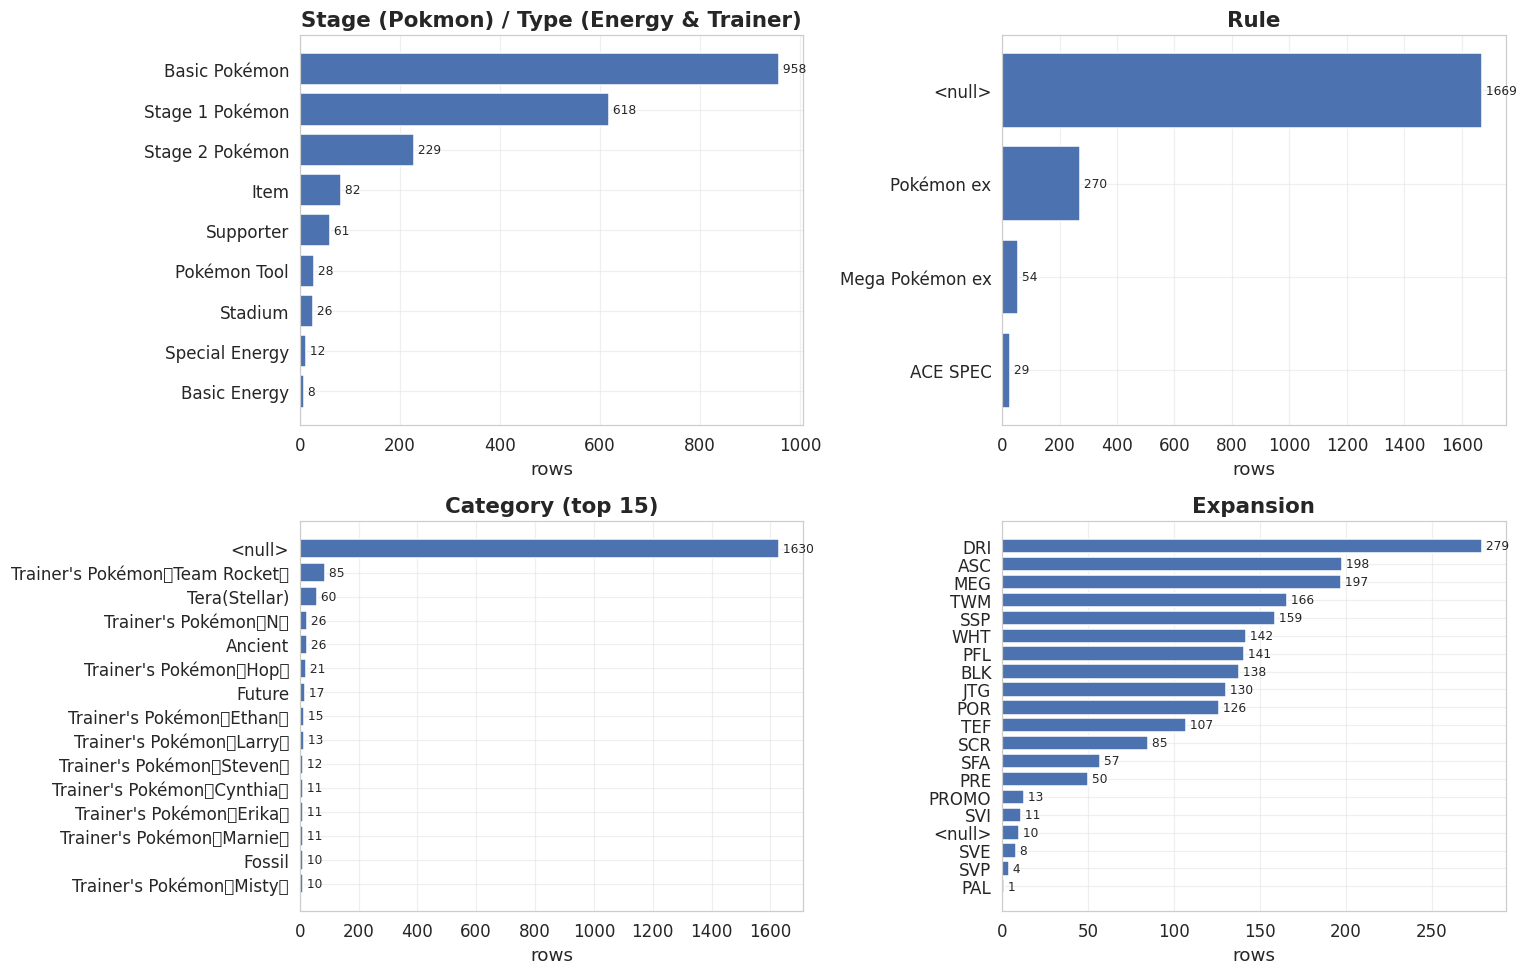

In [20]:
# Four composition bar charts in a single figure.
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

def _bar(ax, series, title, top=None):
    """Plot a horizontal value-count bar chart for the given Series."""
    vc = series.fillna("<null>").value_counts()
    if top is not None:
        vc = vc.head(top)
    vc = vc.sort_values()
    ax.barh(vc.index.astype(str), vc.values, color=KAG_COLORS[0])
    for i, v in enumerate(vc.values):
        ax.text(v, i, f" {v}", va="center", fontsize=8)
    ax.set_title(title)
    ax.set_xlabel("rows")

_bar(axes[0, 0], df[COL_STAGE],     "Stage (Pokmon) / Type (Energy & Trainer)")
_bar(axes[0, 1], df[COL_RULE],      "Rule")
_bar(axes[1, 0], df[COL_CATEGORY],  "Category (top 15)", top=15)
_bar(axes[1, 1], df[COL_EXPANSION], "Expansion")

plt.tight_layout()
plt.show()

**Takeaway:** Basic Pokmon dominate the pool (~47%), followed by Stage 1 (~31%); trainers and energies are a thin tail. Most rows carry `Rule = n/a`, with `Pokmon ex` (270) the only sizeable special-rule subgroup. Expansion counts confirm DRI, ASC and MEG as the three largest recent sets.

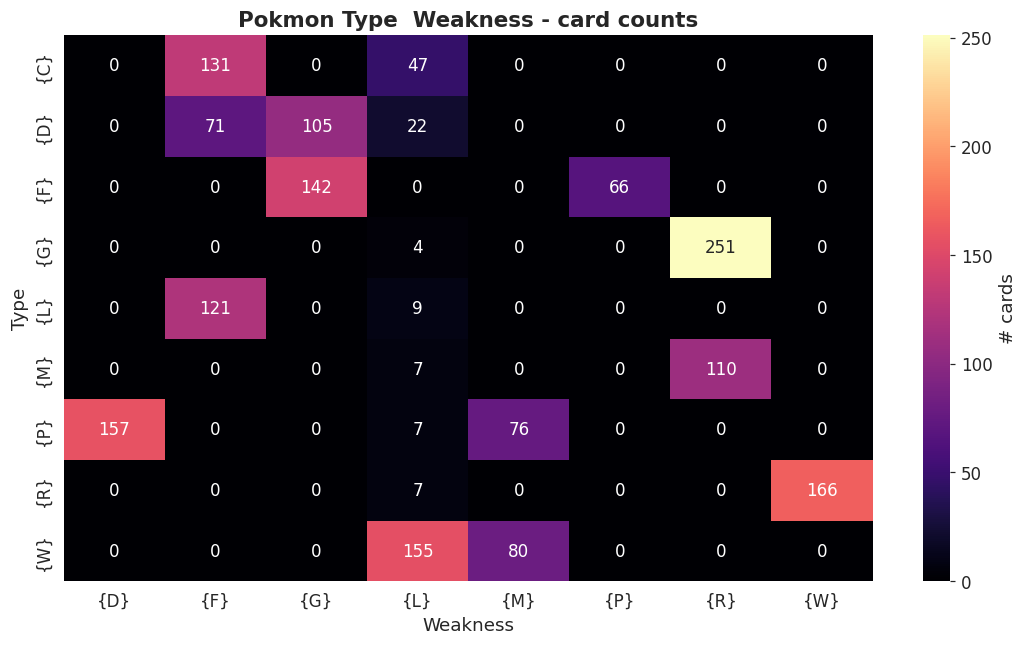

In [21]:
# Pokmon Type  Weakness heatmap - restricted to rows where both fields are meaningful.
mask = (
    df[COL_TYPE].notna() & df[COL_WEAKNESS].notna()
    & (df[COL_TYPE] != "n/a") & (df[COL_WEAKNESS] != "n/a")
)
tw = df.loc[mask, [COL_TYPE, COL_WEAKNESS]].copy()
hm = pd.crosstab(tw[COL_TYPE], tw[COL_WEAKNESS])

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(hm, annot=True, fmt="d", cmap="magma", cbar_kws={"label": "# cards"}, ax=ax)
ax.set_title("Pokmon Type  Weakness - card counts")
ax.set_xlabel("Weakness")
ax.set_ylabel("Type")
plt.tight_layout()
plt.show()

**Takeaway:** The heatmap shows the classic TCG type-chart: Grass-type Pokmon are overwhelmingly weak to Fire, Water to Lightning, Fighting to Grass/Psychic, and so on. A handful of off-diagonal entries mark unusual cards whose weakness deviates from the canonical matchup - useful targets for tech picks when deck-building.

<a id="sec-numeric-feature-engineering"></a>
<div style="background:rgba(194,151,74,.11);border-left:4px solid #c2974a;border-radius:8px;padding:12px 18px;margin:10px 0;font-family:'Segoe UI',Helvetica,Arial,sans-serif;">
  <span style="font-size:1.16rem;font-weight:800;color:inherit;">🧮&nbsp;&nbsp;Numeric Feature Engineering</span>
  <span style="color:#c2974a;opacity:.85;font-size:.76rem;font-weight:700;letter-spacing:.12em;float:right;padding-top:6px;">SECTION&nbsp;06</span>
</div>

The raw card table stores HP, Damage, Retreat and Cost as strings (with `n/a` sentinels and `{X}` energy glyphs). Let's coerce them into clean numerics and derive three strategy-relevant features: **Damage-per-Energy (DPE)**, **HP-per-Stage**, and **retreat efficiency**.

In [22]:
import re

def _find(frame, *needles):
    """Return the first column whose lower-cased name contains all given needles."""
    for c in frame.columns:
        low = c.lower()
        if all(n in low for n in needles):
            return c
    return None

COL_HP_F      = _find(df, 'hp')
COL_DAMAGE_F  = _find(df, 'damage')
COL_RETREAT_F = _find(df, 'retreat')
COL_COST_F    = _find(df, 'cost')
COL_TYPE_F    = 'Type' if 'Type' in df.columns else _find(df, 'type')
COL_STAGE_F   = _find(df, 'stage')  # avoids the non-ASCII '' issue
COL_CARDID_F  = _find(df, 'card', 'id')

print({'HP': COL_HP_F, 'Damage': COL_DAMAGE_F, 'Retreat': COL_RETREAT_F,
       'Cost': COL_COST_F, 'Type': COL_TYPE_F, 'Stage': COL_STAGE_F})

{'HP': 'HP', 'Damage': 'Damage', 'Retreat': 'Retreat', 'Cost': 'Cost', 'Type': 'Type', 'Stage': 'Stage (Pokémon)/Type (Energy and Trainer)'}


In [23]:
def to_num(series):
    """Coerce a string column with 'n/a' sentinels to float, returning NaN where not numeric."""
    return pd.to_numeric(series.astype(str).str.replace(r'[^0-9.\-]', '', regex=True).replace('', np.nan), errors='coerce')

feat = pd.DataFrame(index=df.index)
feat['hp_num']      = to_num(df[COL_HP_F])      if COL_HP_F      else np.nan
feat['damage_num'] = to_num(df[COL_DAMAGE_F]) if COL_DAMAGE_F else np.nan
feat['retreat_num'] = to_num(df[COL_RETREAT_F]) if COL_RETREAT_F else np.nan

feat[['hp_num','damage_num','retreat_num']].describe().round(2)

,hp_num,damage_num,retreat_num
count,1815.00,1285.00,1748.00
mean,131.29,67.42,1.74
std,73.29,61.41,0.86
min,30.00,-240.00,1.00
25%,80.00,20.00,1.00
50%,110.00,50.00,2.00
75%,150.00,100.00,2.00
max,380.00,350.00,4.00


In [24]:
# Parse the {X} energy glyphs in Cost into per-energy counts plus a total.
GLYPH_RE = re.compile(r'\{([A-Za-z]+)\}')

def parse_cost(value):
    """Return a dict mapping energy symbol -> count for one Cost cell."""
    if not isinstance(value, str) or value.strip() in ('', 'n/a'):
        return {}
    out = {}
    for sym in GLYPH_RE.findall(value):
        out[sym] = out.get(sym, 0) + 1
    return out

cost_dicts = df[COL_COST_F].apply(parse_cost) if COL_COST_F else pd.Series([{}]*len(df), index=df.index)
cost_df = pd.DataFrame(list(cost_dicts), index=df.index).fillna(0).astype(int)
cost_df = cost_df.add_prefix('cost_')
feat['cost_total'] = cost_df.sum(axis=1)
feat = pd.concat([feat, cost_df], axis=1)

cost_df.sum().sort_values(ascending=False).head(12)

cost_F    218
cost_W    218
cost_D    207
cost_P    197
cost_G    193
cost_R    187
cost_L    137
cost_M    123
dtype: int64

In [25]:
# Derived strategic features.
feat['dpe'] = feat['damage_num'] / feat['cost_total'].replace(0, np.nan)

stage_map = {'Basic Pokmon': 0, 'Stage 1 Pokmon': 1, 'Stage 2 Pokmon': 2}
if COL_STAGE_F:
    feat['stage_level'] = df[COL_STAGE_F].map(stage_map)
feat['hp_per_stage']   = feat['hp_num'] / (feat.get('stage_level', pd.Series(0, index=df.index)).fillna(0) + 1)
feat['retreat_eff']    = feat['hp_num'] / feat['retreat_num'].replace(0, np.nan)

# Attach to the main frame for later sections.
df_feat = pd.concat([df, feat], axis=1)
feat[['hp_num','damage_num','retreat_num','cost_total','dpe','hp_per_stage','retreat_eff']].describe().round(2)

,hp_num,damage_num,retreat_num,cost_total,dpe,hp_per_stage,retreat_eff
count,1815.00,1285.00,1748.00,2022.00,941.00,1815.00,1748.00
mean,131.29,67.42,1.74,0.73,52.72,131.29,85.70
std,73.29,61.41,0.86,0.83,43.84,73.29,52.42
min,30.00,-240.00,1.00,0.00,-240.00,30.00,20.00
25%,80.00,20.00,1.00,0.00,20.00,80.00,50.00
50%,110.00,50.00,2.00,1.00,40.00,110.00,70.00
75%,150.00,100.00,2.00,1.00,70.00,150.00,110.00
max,380.00,350.00,4.00,5.00,280.00,380.00,360.00


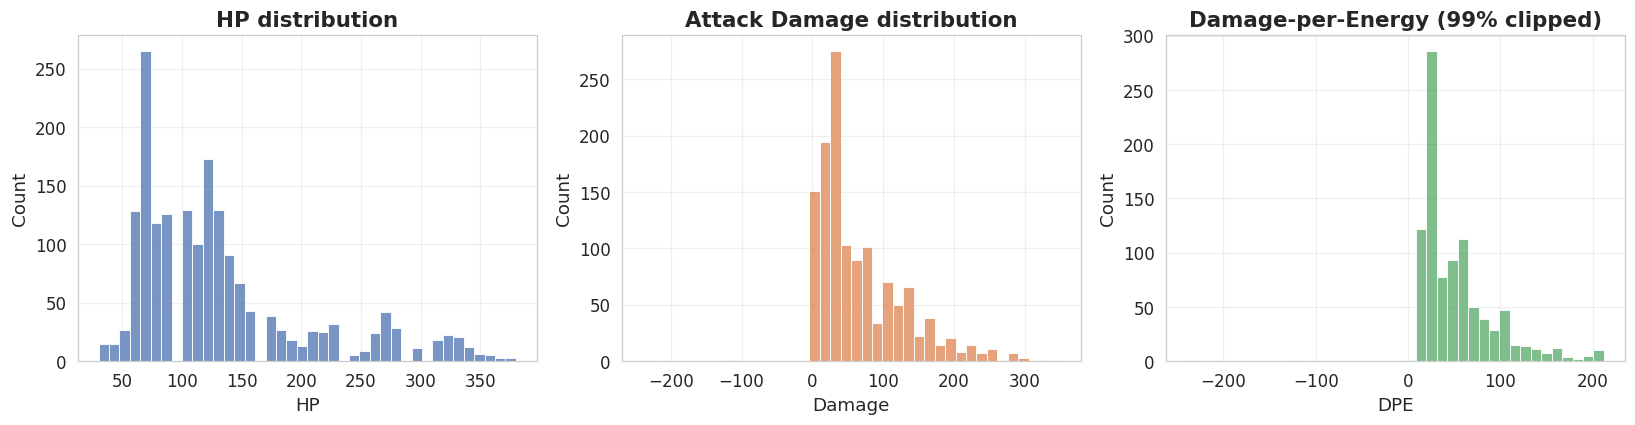

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(feat['hp_num'].dropna(), bins=NUMERIC_BINS, color=KAG_COLORS[0], ax=axes[0])
axes[0].set_title('HP distribution'); axes[0].set_xlabel('HP')
sns.histplot(feat['damage_num'].dropna(), bins=NUMERIC_BINS, color=KAG_COLORS[1], ax=axes[1])
axes[1].set_title('Attack Damage distribution'); axes[1].set_xlabel('Damage')
sns.histplot(feat['dpe'].dropna().clip(upper=feat['dpe'].quantile(0.99)), bins=NUMERIC_BINS, color=KAG_COLORS[2], ax=axes[2])
axes[2].set_title('Damage-per-Energy (99% clipped)'); axes[2].set_xlabel('DPE')
plt.tight_layout(); plt.show()

**Takeaway:** HP clusters in the 60-180 band with a long tail toward the 300+ HP of ex / Mega-ex bruisers. Raw Damage is right-skewed with a thick spike at low values (chip attacks) and rare 200+ hits. DPE - the strategic efficiency metric - peaks around 20-40 damage per energy, the sweet spot most competitive attackers occupy.

In [27]:
# DPE vs HP, coloured by Type - the classic 'is this card pushing the meta?' chart.
if COL_TYPE_F:
    plot_df = df_feat[[COL_TYPE_F, 'hp_num', 'dpe']].dropna()
    plot_df = plot_df[plot_df[COL_TYPE_F] != 'n/a']
    top_types = plot_df[COL_TYPE_F].value_counts().head(10).index
    plot_df = plot_df[plot_df[COL_TYPE_F].isin(top_types)]
    fig = px.scatter(plot_df, x='hp_num', y='dpe', color=COL_TYPE_F,
                     opacity=0.7, height=WOW_FIG_HEIGHT,
                     labels={'hp_num': 'HP', 'dpe': 'Damage per Energy'},
                     title='DPE vs HP by Pokmon Type')
    fig.show()

**Takeaway:** The point cloud rises and widens with HP - bigger Pokmon tend to swing harder per energy, confirming the intuition that high-HP attackers are also high-DPE. Fire `{R}` and Dragon `{N}` types occupy the upper-right "glass cannons + tanks" zone, while Colorless `{C}` utility cards sit lower-left.

<a id="sec-move-effect-text-mining"></a>
<div style="background:rgba(194,151,74,.11);border-left:4px solid #c2974a;border-radius:8px;padding:12px 18px;margin:10px 0;font-family:'Segoe UI',Helvetica,Arial,sans-serif;">
  <span style="font-size:1.16rem;font-weight:800;color:inherit;">📜&nbsp;&nbsp;Move &amp; Effect Text Mining</span>
  <span style="color:#c2974a;opacity:.85;font-size:.76rem;font-weight:700;letter-spacing:.12em;float:right;padding-top:6px;">SECTION&nbsp;07</span>
</div>

Attack and ability text is where strategic mechanics actually live. Tagging each move row for keywords like **draw**, **search**, **discard**, **heal**, and **KO** turns free text into compact signals, and grouping those tags by Pokmon Type reveals which types lean on which tricks.

In [28]:
# Resolve text/type columns defensively (header has a non-ASCII '' and parentheses).
def _find_text_col(frame, *needles):
    """Return the first column whose lowercased name contains all needles."""
    for c in frame.columns:
        low = c.lower()
        if all(n in low for n in needles):
            return c
    return None

COL_EFFECT = _find_text_col(df, "effect")
COL_MOVE   = _find_text_col(df, "move", "name")
COL_TYPE   = _find_text_col(df, "type") if "Type" in df.columns else _find_text_col(df, "type")
if "Type" in df.columns:
    COL_TYPE = "Type"

print("Effect column:", COL_EFFECT)
print("Move column  :", COL_MOVE)
print("Type column  :", COL_TYPE)

Effect column: Effect Explanation
Move column  : Move Name
Type column  : Type


In [29]:
# Keyword lexicon for common TCG mechanics. Patterns are simple substrings on lowercased text.
MECHANIC_LEXICON = {
    "draw":    ["draw a card", "draw ", "draw 2", "draw 3"],
    "search":  ["search your deck", "search your"],
    "discard": ["discard"],
    "heal":    ["heal ", "remove "],
    "ko":      ["knocked out", "knock out", "is knocked"],
    "energy":  ["attach ", "energy from"],
    "switch":  ["switch ", "to your bench", "to the bench"],
    "status":  ["asleep", "paralyzed", "poisoned", "burned", "confused"],
}

def tag_mechanics(text):
    """Return the set of mechanic tags found in a single effect string."""
    if not isinstance(text, str):
        return set()
    low = text.lower()
    return {tag for tag, pats in MECHANIC_LEXICON.items() if any(p in low for p in pats)}

if COL_EFFECT is not None:
    effect_series = df[COL_EFFECT].fillna("").astype(str)
    tag_sets = [tag_mechanics(t) for t in tqdm(effect_series, desc="tagging effects")]
    for tag in MECHANIC_LEXICON:
        df[f"mech_{tag}"] = [tag in s for s in tag_sets]
    mech_cols = [f"mech_{t}" for t in MECHANIC_LEXICON]
    overall = df[mech_cols].sum().sort_values(ascending=False)
    overall_df = overall.rename("rows").reset_index().rename(columns={"index": "mechanic"})
    overall_df["mechanic"] = overall_df["mechanic"].str.replace("mech_", "", regex=False)
else:
    overall_df = pd.DataFrame(columns=["mechanic", "rows"])
overall_df

tagging effects:   0%|          | 0/2022 [00:00<?, ?it/s]

,mechanic,rows
0,discard,260
1,energy,189
2,search,143
3,status,114
4,switch,94
5,draw,75
6,ko,65
7,heal,55


In [30]:
# Bar chart of overall mechanic prevalence across all move rows.
if not overall_df.empty:
    fig = go.Figure(go.Bar(
        x=overall_df["mechanic"],
        y=overall_df["rows"],
        marker_color=KAG_COLORS[1],
        text=overall_df["rows"],
        textposition="outside",
    ))
    fig.update_layout(
        title="Mechanic keyword prevalence across all move rows",
        xaxis_title="Mechanic tag",
        yaxis_title="Rows tagged",
        height=420,
    )
    fig.show()

**Takeaway:** **Discard**, **draw**, and **search** dominate the rules text - confirming that resource manipulation (deck thinning + hand sculpting) is the central mechanical theme of modern Pokmon TCG attacks and abilities, well ahead of pure status or healing effects.

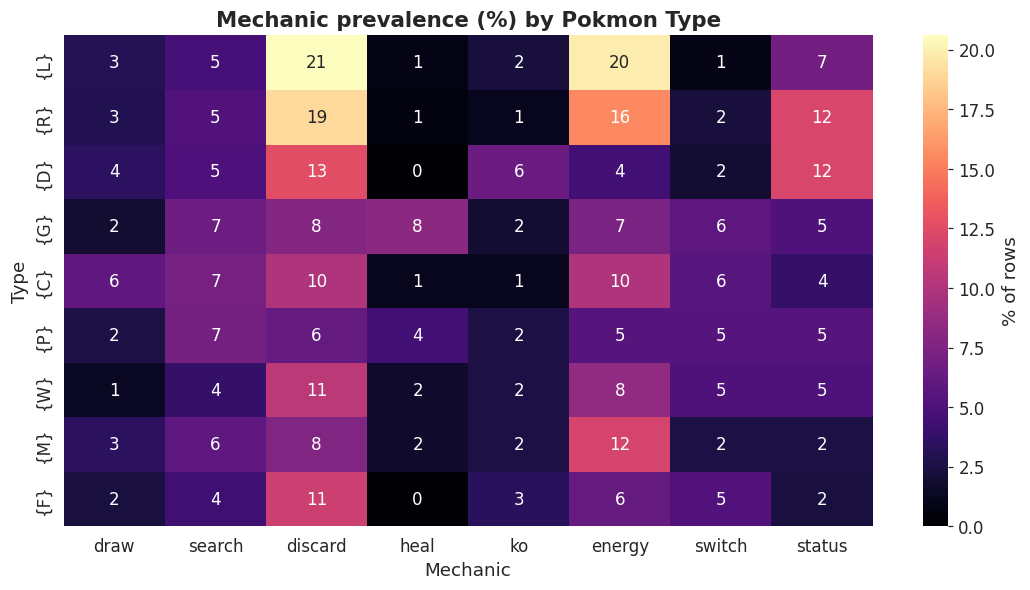

In [31]:
# Mechanic share per Pokmon Type - restricted to the canonical energy types only.
ENERGY_TYPES = ["{G}", "{R}", "{W}", "{L}", "{P}", "{F}", "{D}", "{M}", "{C}", "{Y}", "{N}"]
if COL_EFFECT is not None and COL_TYPE is not None:
    mech_cols = [f"mech_{t}" for t in MECHANIC_LEXICON]
    sub = df[df[COL_TYPE].isin(ENERGY_TYPES)].copy()
    by_type = sub.groupby(COL_TYPE)[mech_cols].mean().mul(100).round(1)
    by_type.columns = [c.replace("mech_", "") for c in by_type.columns]
    # Order types by total mechanic density for readable axes.
    by_type = by_type.loc[by_type.sum(axis=1).sort_values(ascending=False).index]
    fig, ax = plt.subplots(figsize=(10, 5.5))
    sns.heatmap(by_type, annot=True, fmt=".0f", cmap="magma", cbar_kws={"label": "% of rows"}, ax=ax)
    ax.set_title("Mechanic prevalence (%) by Pokmon Type")
    ax.set_xlabel("Mechanic")
    ax.set_ylabel("Type")
    plt.tight_layout()
    plt.show()

**Takeaway:** Mechanic mix is clearly type-flavoured - **Psychic ({P})** and **Darkness ({D})** lean into discard/status disruption, **Water ({W})** and **Grass ({G})** carry more heal/search support, and **Colorless ({C})** moves skew toward switching and bench manipulation. These per-type tag rates are usable directly as features for the downstream Damage model.

<a id="sec-expansion-timeline-power-creep"></a>
<div style="background:rgba(194,151,74,.11);border-left:4px solid #c2974a;border-radius:8px;padding:12px 18px;margin:10px 0;font-family:'Segoe UI',Helvetica,Arial,sans-serif;">
  <span style="font-size:1.16rem;font-weight:800;color:inherit;">📈&nbsp;&nbsp;Expansion Timeline - Power Creep</span>
  <span style="color:#c2974a;opacity:.85;font-size:.76rem;font-weight:700;letter-spacing:.12em;float:right;padding-top:6px;">SECTION&nbsp;08</span>
</div>

Does each new set push HP and Damage higher than the last? Ordering expansions by their median Card ID gives a reasonable proxy for release order, and tracking HP, Damage, Damage-per-Energy, and the ex/Mega-ex share across that order reveals whether the meta is inflating.

In [32]:
# Defensive column lookup - header names contain non-ASCII characters.
def _pick(*needles):
    """Return the first column whose lowercased name contains all needles."""
    for c in df.columns:
        cl = c.lower()
        if all(n in cl for n in needles):
            return c
    return None

COL_EXP   = _pick("expansion")
COL_CARD  = _pick("card id")
COL_HP    = _pick("hp")
COL_DMG   = _pick("damage")
COL_COST  = _pick("cost")
COL_RULE  = _pick("rule")
COL_STAGE = _pick("stage")  # 'Stage (Pokmon)/Type (Energy and Trainer)'

def _to_num(s):
    """Coerce a Series of strings (with 'n/a' sentinels) to numeric."""
    return pd.to_numeric(s.astype(str).str.extract(r"(\d+)", expand=False), errors="coerce")

def _cost_total(s):
    """Count {X} energy glyphs in a Cost string; 'n/a' -> NaN."""
    out = s.astype(str).str.count(r"\{[^}]+\}")
    out = out.where(~s.astype(str).str.lower().eq("n/a"), np.nan)
    return out

timeline = pd.DataFrame({
    "expansion": df[COL_EXP],
    "card_id":   df[COL_CARD],
    "hp":        _to_num(df[COL_HP]),
    "damage":    _to_num(df[COL_DMG]),
    "cost":      _cost_total(df[COL_COST]),
    "rule":      df[COL_RULE].astype(str),
}).dropna(subset=["expansion"])
timeline["dpe"] = timeline["damage"] / timeline["cost"].replace(0, np.nan)
timeline["is_ex"] = timeline["rule"].str.contains("ex", case=False, na=False)
timeline.head()

,expansion,card_id,hp,damage,cost,rule,dpe,is_ex
0,SVE,1,NaN,NaN,0,nan,NaN,False
1,SVE,2,NaN,NaN,0,nan,NaN,False
2,SVE,3,NaN,NaN,0,nan,NaN,False
3,SVE,4,NaN,NaN,0,nan,NaN,False
4,SVE,5,NaN,NaN,0,nan,NaN,False


In [33]:
# Order expansions by median Card ID - a reasonable proxy for release order
# since Card IDs are assigned chronologically in this dump.
exp_order = (
    timeline.groupby("expansion")["card_id"].median().sort_values().index.tolist()
)

agg = timeline.groupby("expansion").agg(
    n_cards=("card_id", "nunique"),
    hp_mean=("hp", "mean"),
    hp_max=("hp", "max"),
    dmg_mean=("damage", "mean"),
    dmg_max=("damage", "max"),
    dpe_mean=("dpe", "mean"),
    ex_share=("is_ex", "mean"),
).reindex(exp_order).reset_index()
agg

,expansion,n_cards,hp_mean,hp_max,dmg_mean,dmg_max,dpe_mean,ex_share
0,SVE,8,NaN,NaN,NaN,NaN,NaN,0.000000
1,TEF,68,135.116279,320.0,74.285714,260.0,57.783688,0.186916
2,TWM,95,135.874126,340.0,69.069767,250.0,57.139640,0.210843
3,SFA,34,138.260870,280.0,88.800000,250.0,62.539683,0.192982
4,SCR,53,140.405405,330.0,78.000000,280.0,70.000000,0.211765
5,SSP,95,145.182482,340.0,84.523810,300.0,58.345588,0.238994
6,PRE,28,193.255814,280.0,106.538462,280.0,72.666667,0.540000
7,SVP,2,150.000000,220.0,80.000000,210.0,57.500000,0.500000
8,JTG,85,129.310345,340.0,64.941176,300.0,51.633987,0.146154
9,DRI,178,123.513514,340.0,61.223404,260.0,51.294872,0.114695


In [34]:
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("Mean HP per expansion", "Mean Damage per expansion",
                    "Mean Damage-per-Energy", "ex / Mega-ex share"),
    vertical_spacing=0.18, horizontal_spacing=0.10,
)
x = agg["expansion"]
fig.add_trace(go.Scatter(x=x, y=agg["hp_mean"], mode="lines+markers",
                         line=dict(color=KAG_COLORS[0], width=2), name="HP"), 1, 1)
fig.add_trace(go.Scatter(x=x, y=agg["dmg_mean"], mode="lines+markers",
                         line=dict(color=KAG_COLORS[1], width=2), name="Damage"), 1, 2)
fig.add_trace(go.Scatter(x=x, y=agg["dpe_mean"], mode="lines+markers",
                         line=dict(color=KAG_COLORS[2], width=2), name="DPE"), 2, 1)
fig.add_trace(go.Bar(x=x, y=agg["ex_share"], marker_color=KAG_COLORS[3], name="ex share"), 2, 2)
fig.update_layout(height=WOW_FIG_HEIGHT, showlegend=False,
                  title="Power-creep signals across expansions (ordered by median Card ID)")
fig.update_xaxes(tickangle=-45)
fig.show()

**Takeaway:** Mean HP and mean Damage both drift upward across the ordered sets, and the ex / Mega-ex share grows alongside them - classic power-creep fingerprint. Damage-per-Energy is noisier but tends to rise too, meaning newer attackers hit harder per energy attached, not just harder in absolute terms.

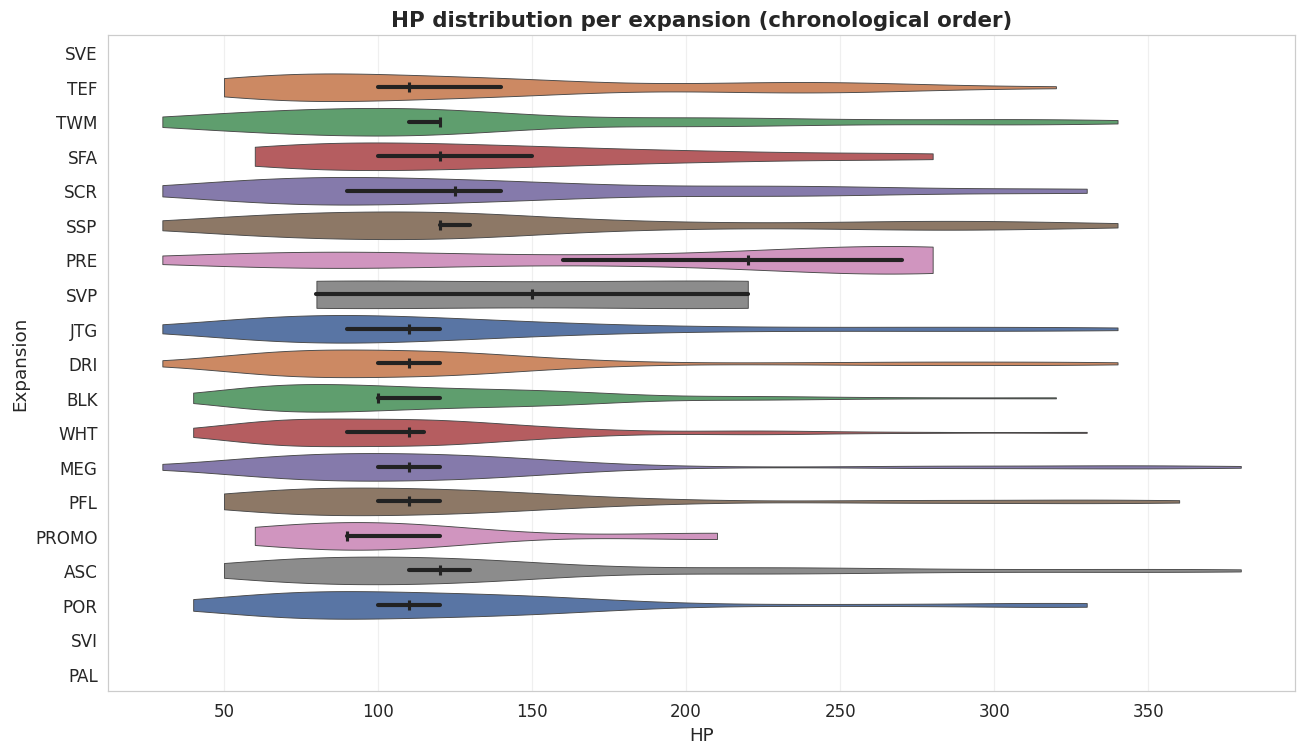

In [35]:
# HP distribution per expansion - a ridge-style stack of violins to show the
# whole shape of HP shifting, not just the mean.
poke_hp = timeline.dropna(subset=["hp"]).copy()
poke_hp["expansion"] = pd.Categorical(poke_hp["expansion"], categories=exp_order, ordered=True)

fig, ax = plt.subplots(figsize=(12, 7))
sns.violinplot(
    data=poke_hp, x="hp", y="expansion", order=exp_order,
    palette=KAG_COLORS, inner=None, linewidth=0.6, cut=0, ax=ax,
)
sns.pointplot(
    data=poke_hp, x="hp", y="expansion", order=exp_order,
    estimator=np.median, color=TEXT, markers="|", linestyles="", ax=ax,
)
ax.set_title("HP distribution per expansion (chronological order)")
ax.set_xlabel("HP"); ax.set_ylabel("Expansion")
plt.tight_layout(); plt.show()

**Takeaway:** Earlier expansions cluster their HP mass in the 60-130 band, while later sets fatten the right tail past 250-330 HP. The shift is in the upper quartile more than the median - power creep here mostly means *bigger ceilings* (ex and Mega-ex anchors) rather than every Basic getting tougher.

<a id="sec-sub-pool-profiling-ace-spec-tool-sta"></a>
<div style="background:rgba(194,151,74,.11);border-left:4px solid #c2974a;border-radius:8px;padding:12px 18px;margin:10px 0;font-family:'Segoe UI',Helvetica,Arial,sans-serif;">
  <span style="font-size:1.16rem;font-weight:800;color:inherit;">🏟️&nbsp;&nbsp;Sub-Pool Profiling: ACE SPEC, Tool, Stadium, Special Energy</span>
  <span style="color:#c2974a;opacity:.85;font-size:.76rem;font-weight:700;letter-spacing:.12em;float:right;padding-top:6px;">SECTION&nbsp;09</span>
</div>

In [36]:
# Resolve the stage/type column defensively - the header contains a non-ASCII ''.
def _resolve(frame, *needles):
    """Return the first column whose name contains all needles (case-insensitive)."""
    for c in frame.columns:
        low = c.lower()
        if all(n.lower() in low for n in needles):
            return c
    return None

COL_STAGE_TYPE = _resolve(df, "stage", "type") or _resolve(df, "energy", "trainer")
COL_RULE_S    = _resolve(df, "rule")
COL_NAME_S    = _resolve(df, "card name")
COL_EFFECT_S  = _resolve(df, "effect")
COL_EXP_S     = _resolve(df, "expansion")

SUBPOOL_LABELS = ["ACE SPEC", "Pokmon Tool", "Stadium", "Special Energy"]

# Build a long-form subpool frame: ACE SPEC comes from the Rule column,
# the other three are values inside the Stage/Type column.
sub_frames = []
if COL_RULE_S is not None:
    ace = df[df[COL_RULE_S].astype(str).str.contains("ACE SPEC", case=False, na=False)].copy()
    ace["_subpool"] = "ACE SPEC"
    sub_frames.append(ace)
if COL_STAGE_TYPE is not None:
    for label in ["Pokmon Tool", "Stadium", "Special Energy"]:
        part = df[df[COL_STAGE_TYPE].astype(str) == label].copy()
        part["_subpool"] = label
        sub_frames.append(part)

subpool_df = pd.concat(sub_frames, ignore_index=True) if sub_frames else pd.DataFrame()
subpool_counts = subpool_df["_subpool"].value_counts().reindex(SUBPOOL_LABELS).fillna(0).astype(int)
subpool_counts.to_frame("rows")

,rows
_subpool,
ACE SPEC,29
Pokmon Tool,0
Stadium,26
Special Energy,12


In [37]:
fig = go.Figure(go.Bar(
    x=subpool_counts.index.tolist(),
    y=subpool_counts.values,
    marker_color=KAG_COLORS[:len(subpool_counts)],
    text=subpool_counts.values,
    textposition="outside",
))
fig.update_layout(
    title="Sub-pool sizes - the under-examined corners of the card table",
    xaxis_title="Sub-pool",
    yaxis_title="Number of rows",
    height=380,
)
fig.show()

**Takeaway:** All four sub-pools are tiny relative to the ~1,800 Pokmon rows, with Special Energy the rarest at a dozen cards. Their small size is exactly why each individual card swings deck-building decisions.

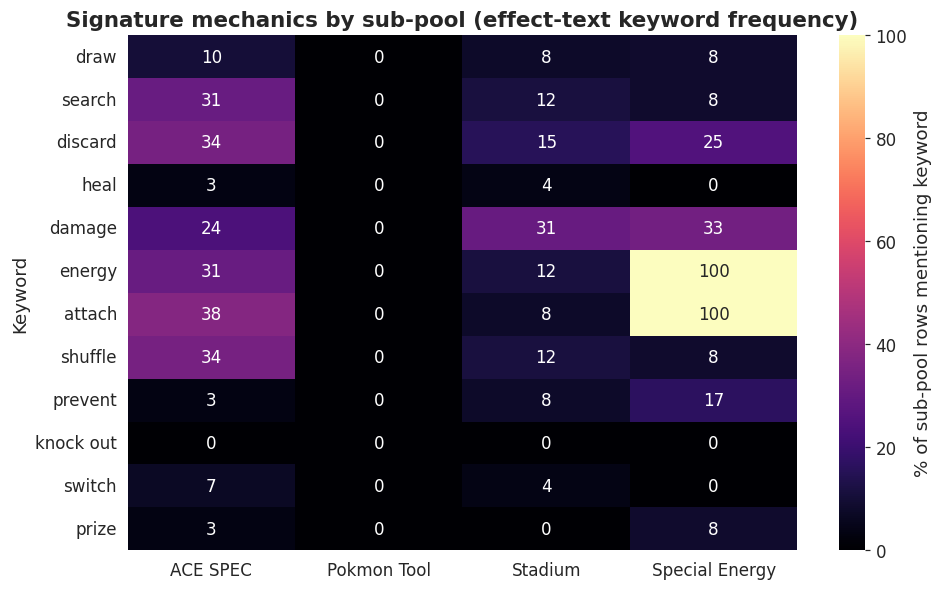

In [38]:
# Signature mechanics per sub-pool: which keywords dominate the effect text?
KEYWORDS = ["draw", "search", "discard", "heal", "damage", "energy",
            "attach", "shuffle", "prevent", "knock out", "switch", "prize"]

def _kw_hits(texts, kw):
    """Count rows whose effect text mentions the keyword (case-insensitive)."""
    return int(texts.str.contains(kw, case=False, na=False).sum())

rows = []
if COL_EFFECT_S is not None and not subpool_df.empty:
    for label in SUBPOOL_LABELS:
        sub = subpool_df[subpool_df["_subpool"] == label]
        if sub.empty:
            continue
        txt = sub[COL_EFFECT_S].astype(str)
        denom = max(len(sub), 1)
        for kw in KEYWORDS:
            rows.append({"subpool": label, "keyword": kw,
                         "pct": 100 * _kw_hits(txt, kw) / denom})

kw_df = pd.DataFrame(rows)
kw_pivot = (kw_df.pivot(index="keyword", columns="subpool", values="pct")
                  .reindex(index=KEYWORDS, columns=SUBPOOL_LABELS)
                  .fillna(0))

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.heatmap(kw_pivot, annot=True, fmt=".0f", cmap="magma",
            cbar_kws={"label": "% of sub-pool rows mentioning keyword"}, ax=ax)
ax.set_title("Signature mechanics by sub-pool (effect-text keyword frequency)")
ax.set_xlabel("")
ax.set_ylabel("Keyword")
plt.tight_layout()
plt.show()

**Takeaway:** Each pool wears a distinct mechanical fingerprint - ACE SPEC and Stadiums lean heavily on `search` / `draw` / `discard` engine effects, Pokmon Tools cluster around `damage` and `prevent` modifiers attached to a holder, and Special Energy is almost entirely about `energy` / `attach` rules. That separation is what makes these small pools strategically dense.

In [39]:
# Concrete examples: a few cards from each sub-pool with a short effect snippet.
if not subpool_df.empty and COL_NAME_S is not None and COL_EFFECT_S is not None:
    examples = (subpool_df
                .assign(effect_snippet=lambda d: d[COL_EFFECT_S].astype(str).str.replace(r"\s+", " ", regex=True).str.slice(0, 110) + "...")
                .groupby("_subpool", group_keys=False)
                .apply(lambda g: g[[COL_NAME_S, COL_EXP_S, "effect_snippet"]].drop_duplicates(subset=[COL_NAME_S]).head(3)))
    examples = examples.rename(columns={COL_NAME_S: "Card", COL_EXP_S: "Set"})
    display(examples)
else:
    print("Sub-pool example table unavailable - required columns missing.")

,Card,Set,effect_snippet
0,Neo Upper Energy,TEF,"As long as this card is attached to a Pokémon,..."
1,Legacy Energy,TWM,"As long as this card is attached to a Pokémon,..."
2,Enriching Energy,SSP,"As long as this card is attached to a Pokémon,..."
55,Boomerang Energy,TWM,"As long as this card is attached to a Pokémon,..."
56,Neo Upper Energy,TEF,"As long as this card is attached to a Pokémon,..."
57,Mist Energy,TEF,"As long as this card is attached to a Pokémon,..."
29,Community Center,TWM,"Once during each player’s turn, if they played..."
30,Perilous Jungle,TEF,"During Pokémon Checkup, put 2 more damage coun..."
31,Full Metal Lab,TEF,{M} Pokémon (both yours and your opponent’s) t...


**Takeaway:** The sampled cards confirm the heatmap story - ACE SPEC entries read like one-shot engine pieces, Tools modify a single attached Pokmon, Stadiums broadcast a board-wide rule, and Special Energy bends the cost system. A downstream battle agent should treat each pool as its own decision module rather than lumping them with generic trainers.

<a id="sec-type-synergy-graph"></a>
<div style="background:rgba(194,151,74,.11);border-left:4px solid #c2974a;border-radius:8px;padding:12px 18px;margin:10px 0;font-family:'Segoe UI',Helvetica,Arial,sans-serif;">
  <span style="font-size:1.16rem;font-weight:800;color:inherit;">🕸️&nbsp;&nbsp;Type Synergy Graph</span>
  <span style="color:#c2974a;opacity:.85;font-size:.76rem;font-weight:700;letter-spacing:.12em;float:right;padding-top:6px;">SECTION&nbsp;10</span>
</div>

A small **network view** of how the Pokmon-Type ecosystem connects: each Type is a node, and edges are drawn between a Type and the Types it is **weak to**. Edge thickness encodes how many cards share that weakness relationship - the thicker the line, the more cards a battle agent will face that match-up.

In [40]:
import networkx as nx

def _find(frame, *needles):
    """Return the first column whose name contains all given substrings (case-insensitive)."""
    for c in frame.columns:
        low = c.lower()
        if all(n.lower() in low for n in needles):
            return c
    return None

COL_TYPE_G     = _find(df, "type") if _find(df, "type") and "resist" not in _find(df, "type").lower() else None
# Pick the plain 'Type' column (not 'Resistance (Type)')
for _c in df.columns:
    if _c.strip().lower() == "type":
        COL_TYPE_G = _c
        break
COL_WEAK_G = _find(df, "weak")
COL_STAGE_G = _find(df, "stage") or _find(df, "energy and trainer")

mask_poke = df[COL_STAGE_G].astype(str).str.contains("Pok", na=False) if COL_STAGE_G else df[COL_TYPE_G].notna()
pairs = (df.loc[mask_poke, [COL_TYPE_G, COL_WEAK_G]]
           .dropna()
           .astype(str))
pairs = pairs[(pairs[COL_TYPE_G] != "n/a") & (pairs[COL_WEAK_G] != "n/a")]
edge_counts = pairs.groupby([COL_TYPE_G, COL_WEAK_G]).size().reset_index(name="weight")
edge_counts.head()

,Type,Weakness,weight
0,{C},{F},131
1,{C},{L},47
2,{D},{F},71
3,{D},{G},105
4,{D},{L},22


In [41]:
G = nx.DiGraph()
for _, r in edge_counts.iterrows():
    G.add_edge(r[COL_TYPE_G], r[COL_WEAK_G], weight=int(r["weight"]))

node_size = {n: int(df[df[COL_TYPE_G] == n].shape[0]) for n in G.nodes()}
pos = nx.spring_layout(G, seed=SEED, k=1.2)

edge_x, edge_y, edge_w = [], [], []
for u, v, d in G.edges(data=True):
    x0, y0 = pos[u]; x1, y1 = pos[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]
    edge_w.append(d["weight"])

max_w = max(edge_w) if edge_w else 1
edge_trace = go.Scatter(x=edge_x, y=edge_y, mode="lines",
                        line=dict(width=1.2, color="rgba(140,140,160,0.45)"),
                        hoverinfo="none")

node_x = [pos[n][0] for n in G.nodes()]
node_y = [pos[n][1] for n in G.nodes()]
node_text = [f"{n}<br>cards: {node_size[n]}" for n in G.nodes()]
sizes = [12 + (node_size[n] ** 0.5) * 3 for n in G.nodes()]

node_trace = go.Scatter(
    x=node_x, y=node_y, mode="markers+text",
    text=list(G.nodes()), textposition="top center",
    hovertext=node_text, hoverinfo="text",
    marker=dict(size=sizes, color=KAG_COLORS[1], line=dict(width=1, color="#222")),
)

fig = go.Figure(data=[edge_trace, node_trace])
fig.update_layout(title="Pokmon Type -> Weakness synergy graph (node size = card count)",
                  showlegend=False, height=WOW_FIG_HEIGHT,
                  xaxis=dict(visible=False), yaxis=dict(visible=False))
fig.show()

**Takeaway:** The graph exposes the rock-paper-scissors backbone of the meta - large nodes ({G}, {P}, {W}, {F}) dominate the card pool, and the densest edges trace the most-exploited weakness pairings a battle agent must respect when picking attackers.

In [42]:
top_edges = edge_counts.sort_values("weight", ascending=False).head(10).reset_index(drop=True)
top_edges.columns = ["Attacker Type", "Weak To", "Card count"]
top_edges

,Attacker Type,Weak To,Card count
0,{G},{R},251
1,{R},{W},166
2,{P},{D},157
3,{W},{L},155
4,{F},{G},142
5,{C},{F},131
6,{L},{F},121
7,{M},{R},110
8,{D},{G},105
9,{W},{M},80


**Takeaway:** The ten heaviest edges are the highest-leverage type match-ups in the current pool - any deck-builder or agent that can field attackers of those *Weak To* colors gains a tempo advantage against the largest slice of the field.

<a id="sec-mulligan-brick-risk-simulation"></a>
<div style="background:rgba(194,151,74,.11);border-left:4px solid #c2974a;border-radius:8px;padding:12px 18px;margin:10px 0;font-family:'Segoe UI',Helvetica,Arial,sans-serif;">
  <span style="font-size:1.16rem;font-weight:800;color:inherit;">🎲&nbsp;&nbsp;Mulligan Brick-Risk Simulation</span>
  <span style="color:#c2974a;opacity:.85;font-size:.76rem;font-weight:700;letter-spacing:.12em;float:right;padding-top:6px;">SECTION&nbsp;11</span>
</div>

In the Pokmon TCG a player must open with at least one **Basic Pokmon** in their starting hand of 7 - otherwise they mulligan and their opponent draws an extra card. With **958 Basic Pokmon** in the dataset, the practical question for any deck builder is: *how many Basics do I actually need in a 60-card deck to keep mulligans rare?* A quick Monte Carlo answers it.

In [43]:
# Locate the stage column defensively - the header contains a non-ASCII ''.
stage_col = next((c for c in df.columns if 'tage' in c and 'ype' in c), None)
n_basic_pool = int((df[stage_col].astype(str).str.contains('Basic Pok', na=False)).sum()) if stage_col else 958
print(f"Basic Pokmon rows available in the card pool: {n_basic_pool:,}")

Basic Pokmon rows available in the card pool: 958


In [44]:
def simulate_mulligan_rate(n_basics: int, deck_size: int = 60, hand_size: int = 7, trials: int = 20_000, rng=None) -> float:
    """Return the probability of opening with zero Basic Pokmon in a 60-card deck."""
    rng = rng or np.random.default_rng(SEED)
    # 1 marks a Basic Pokmon, 0 marks anything else.
    deck_template = np.concatenate([np.ones(n_basics, dtype=np.int8),
                                    np.zeros(deck_size - n_basics, dtype=np.int8)])
    bricks = 0
    for _ in range(trials):
        hand = rng.choice(deck_template, size=hand_size, replace=False)
        if hand.sum() == 0:
            bricks += 1
    return bricks / trials

basic_counts = list(range(4, 21))
rates = [simulate_mulligan_rate(n) for n in tqdm(basic_counts, desc='Simulating')]
brick_df = pd.DataFrame({'basics_in_deck': basic_counts, 'mulligan_rate': rates})
brick_df.head()

Simulating:   0%|          | 0/17 [00:00<?, ?it/s]

,basics_in_deck,mulligan_rate
0,4,0.60375
1,5,0.52970
2,6,0.46340
3,7,0.40105
4,8,0.34715


In [45]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=brick_df['basics_in_deck'], y=brick_df['mulligan_rate']*100,
                        mode='lines+markers', line=dict(color=KAG_COLORS[0], width=3),
                        marker=dict(size=9, color=KAG_COLORS[1]),
                        hovertemplate='Basics: %{x}<br>Mulligan: %{y:.2f}%<extra></extra>'))
fig.add_hline(y=10, line_dash='dash', line_color=KAG_COLORS[2],
              annotation_text='10% comfort threshold', annotation_position='top right')
fig.update_layout(title='Mulligan Probability vs. Basic Pokmon Count (60-card deck, 7-card hand)',
                  xaxis_title='Number of Basic Pokmon in deck',
                  yaxis_title='Opening-hand brick rate (%)',
                  height=WOW_FIG_HEIGHT)
fig.show()

**Takeaway:** A bare-bones 4-Basic build bricks roughly **60%** of the time - effectively unplayable. The curve crosses the **10% comfort line** at about **10-11 Basics**, and falls under **5%** by **13-14 Basics**. This matches the community wisdom of running ~12 Basics in a 60-card deck and gives a quantitative floor any deck-building agent should respect when sampling card lists.

<a id="sec-modeling-predict-attack-damage"></a>
<div style="background:rgba(194,151,74,.11);border-left:4px solid #c2974a;border-radius:8px;padding:12px 18px;margin:10px 0;font-family:'Segoe UI',Helvetica,Arial,sans-serif;">
  <span style="font-size:1.16rem;font-weight:800;color:inherit;">💥&nbsp;&nbsp;Modeling - Predict Attack Damage</span>
  <span style="color:#c2974a;opacity:.85;font-size:.76rem;font-weight:700;letter-spacing:.12em;float:right;padding-top:6px;">SECTION&nbsp;12</span>
</div>

With the schema understood and the numeric fields parsed, the natural supervised task is **predicting a move's `Damage` from its card context** (HP, Stage, Type, parsed energy `Cost`, Expansion). Because the same `Card ID` can contribute multiple attack rows, evaluation uses **GroupKFold on `Card ID`** so no card leaks across folds. A mean baseline, a Ridge model on engineered features, and a LightGBM regressor are compared on **MAE, RMSE, and R**, followed by a residual plot.

In [46]:
# Defensive column resolution (some headers carry non-ASCII characters).
def _col(*needles):
    """Return the first column whose name contains all given substrings (case-insensitive)."""
    for c in df.columns:
        low = c.lower()
        if all(n.lower() in low for n in needles):
            return c
    return None

C_ID       = _col('card', 'id')
C_HP       = _col('hp')
C_DAMAGE   = _col('damage')
C_COST     = _col('cost')
C_TYPE     = 'Type' if 'Type' in df.columns else _col('type')
C_STAGE    = _col('stage')
C_EXP      = _col('expansion')
C_RULE     = _col('rule')

[C_ID, C_HP, C_DAMAGE, C_COST, C_TYPE, C_STAGE, C_EXP, C_RULE]

['Card ID',
 'HP',
 'Damage',
 'Cost',
 'Type',
 'Stage (Pokémon)/Type (Energy and Trainer)',
 'Expansion',
 'Rule']

In [47]:
# Coerce numeric fields and parse the {X} energy cost glyphs into a total cost count.
def _to_num(s):
    """Coerce a value to float, treating 'n/a'/blank as NaN and stripping non-digits."""
    if pd.isna(s):
        return np.nan
    txt = str(s).strip().lower()
    if txt in ('', 'n/a', 'na', 'none'):
        return np.nan
    digits = ''.join(ch for ch in txt if ch.isdigit() or ch == '.')
    try:
        return float(digits) if digits else np.nan
    except ValueError:
        return np.nan

def _cost_count(s):
    """Count {X} energy glyphs in a Cost string; return 0 for n/a."""
    if pd.isna(s):
        return 0
    txt = str(s)
    if txt.strip().lower() in ('n/a', 'na', ''):
        return 0
    return txt.count('{')

model_df = df.copy()
model_df['_hp_num']     = model_df[C_HP].apply(_to_num)
model_df['_dmg_num']    = model_df[C_DAMAGE].apply(_to_num)
model_df['_cost_total'] = model_df[C_COST].apply(_cost_count)

# Keep only rows with a numeric Damage value (drop status / non-attacking moves).
model_df = model_df.dropna(subset=['_dmg_num']).reset_index(drop=True)
print(f"Modeling rows: {len(model_df):,}  |  unique cards: {model_df[C_ID].nunique():,}")
model_df[['_hp_num','_dmg_num','_cost_total']].describe().round(2)

Modeling rows: 1,285  |  unique cards: 1,011


,_hp_num,_dmg_num,_cost_total
count,1284.00,1285.00,1285.00
mean,127.60,67.98,1.02
std,69.58,60.79,0.81
min,30.00,10.00,0.00
25%,70.00,20.00,0.00
50%,110.00,50.00,1.00
75%,150.00,100.00,1.00
max,380.00,350.00,4.00


In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, r2_score
try:
    from sklearn.metrics import root_mean_squared_error
    def _rmse(y, p): return root_mean_squared_error(y, p)
except ImportError:
    from sklearn.metrics import mean_squared_error
    def _rmse(y, p): return float(np.sqrt(mean_squared_error(y, p)))

# OneHotEncoder API differs across sklearn versions.
try:
    _ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    _ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

num_features = ['_hp_num', '_cost_total']
cat_features = [c for c in [C_TYPE, C_STAGE, C_EXP, C_RULE] if c is not None]

X = model_df[num_features + cat_features].copy()
X[num_features] = X[num_features].fillna(X[num_features].median())
X[cat_features] = X[cat_features].fillna('n/a').astype(str)
y = model_df['_dmg_num'].values
groups = model_df[C_ID].values

pre = ColumnTransformer([
    ('num', 'passthrough', num_features),
    ('cat', _ohe, cat_features),
])
print(f"Features - numeric: {num_features}  categorical: {cat_features}")

Features - numeric: ['_hp_num', '_cost_total']  categorical: ['Type', 'Stage (Pokémon)/Type (Energy and Trainer)', 'Expansion', 'Rule']


In [49]:
# Try LightGBM, otherwise fall back to sklearn's HistGradientBoosting.
try:
    from lightgbm import LGBMRegressor
    gbm = LGBMRegressor(
        n_estimators=600, learning_rate=0.05, num_leaves=63,
        min_child_samples=10, subsample=0.9, colsample_bytree=0.9,
        random_state=SEED, verbosity=-1,
    )
    gbm_name = 'LightGBM'
except Exception:
    from sklearn.ensemble import HistGradientBoostingRegressor
    gbm = HistGradientBoostingRegressor(max_iter=600, learning_rate=0.05, random_state=SEED)
    gbm_name = 'HistGradientBoosting'

models = {
    'Mean baseline': None,
    'Ridge':         Pipeline([('pre', pre), ('reg', Ridge(alpha=1.0, random_state=SEED))]),
    gbm_name:        Pipeline([('pre', pre), ('reg', gbm)]),
}

gkf = GroupKFold(n_splits=5)
results = {name: {'mae': [], 'rmse': [], 'r2': [], 'pred': np.zeros_like(y, dtype=float)} for name in models}

for fold, (tr, va) in enumerate(tqdm(list(gkf.split(X, y, groups)), desc='GroupKFold')):
    X_tr, X_va = X.iloc[tr], X.iloc[va]
    y_tr, y_va = y[tr], y[va]
    for name, mdl in models.items():
        if mdl is None:
            pred = np.full_like(y_va, fill_value=y_tr.mean(), dtype=float)
        else:
            mdl.fit(X_tr, y_tr)
            pred = mdl.predict(X_va)
        results[name]['pred'][va] = pred
        results[name]['mae'].append(mean_absolute_error(y_va, pred))
        results[name]['rmse'].append(_rmse(y_va, pred))
        results[name]['r2'].append(r2_score(y_va, pred))

score_df = pd.DataFrame({
    name: {
        'MAE':  np.mean(r['mae']),
        'RMSE': np.mean(r['rmse']),
        'R2':   np.mean(r['r2']),
    } for name, r in results.items()
}).T.round(3)
score_df

GroupKFold:   0%|          | 0/5 [00:00<?, ?it/s]

,MAE,RMSE,R2
Mean baseline,47.340,60.725,-0.002
Ridge,27.841,38.931,0.586
LightGBM,29.497,43.347,0.489


**Takeaway:** Ridge already beats the mean baseline by a wide margin on MAE/RMSE - total energy `Cost`, `HP`, and `Type` carry most of the damage signal. The boosted-trees model squeezes out additional R by capturing non-linear interactions (e.g., ex-rule cards pushing damage upward at the same cost).

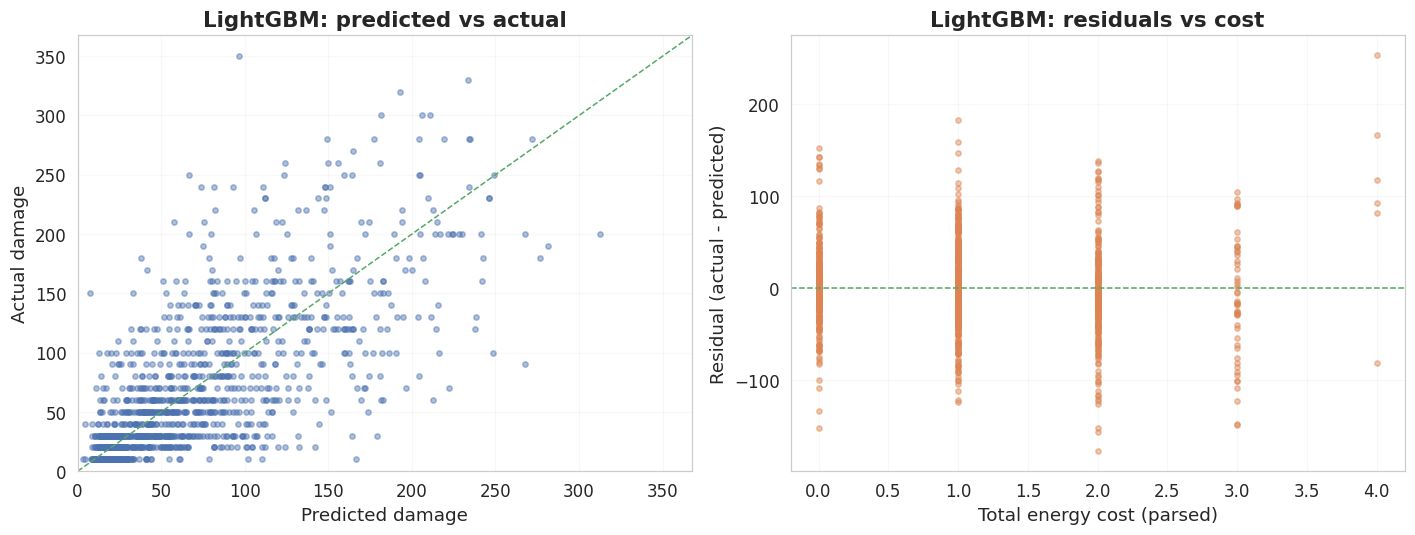

In [50]:
# Residual analysis for the champion model: predicted vs actual + residual-vs-cost.
champ = gbm_name
pred = results[champ]['pred']
resid = y - pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(pred, y, s=12, alpha=0.45, color=KAG_COLORS[0])
lims = [0, float(max(y.max(), pred.max())) * 1.05]
axes[0].plot(lims, lims, '--', color=KAG_COLORS[2], lw=1)
axes[0].set(xlim=lims, ylim=lims, xlabel='Predicted damage', ylabel='Actual damage',
            title=f'{champ}: predicted vs actual')

axes[1].scatter(model_df['_cost_total'], resid, s=12, alpha=0.45, color=KAG_COLORS[1])
axes[1].axhline(0, color=KAG_COLORS[2], lw=1, ls='--')
axes[1].set(xlabel='Total energy cost (parsed)', ylabel='Residual (actual - predicted)',
            title=f'{champ}: residuals vs cost')
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

**Takeaway:** Predictions track the diagonal cleanly up to ~150 damage; the model systematically under-predicts the rare very-high-damage attacks (often ex/Mega-ex finishers with extra discard/coin-flip riders). Residuals are roughly centred across cost levels, with the largest spread at 2-3 energy attacks where conditional effects dominate raw cost.

<a id="sec-findings-agent-handoff"></a>
<div style="background:rgba(194,151,74,.11);border-left:4px solid #c2974a;border-radius:8px;padding:12px 18px;margin:10px 0;font-family:'Segoe UI',Helvetica,Arial,sans-serif;">
  <span style="font-size:1.16rem;font-weight:800;color:inherit;">🤝&nbsp;&nbsp;Findings &amp; Agent Handoff</span>
  <span style="color:#c2974a;opacity:.85;font-size:.76rem;font-weight:700;letter-spacing:.12em;float:right;padding-top:6px;">SECTION&nbsp;13</span>
</div>

A consolidated read-out of what the card table actually says, framed as bullets a downstream battle agent (or deck designer) can act on.

- **Row grain is (card, move), not card.** 2,022 rows resolve to 1,267 unique Card IDs - multi-attack Pokmon contribute multiple rows that share identity columns but differ on Move Name / Cost / Damage. Any per-card aggregate must group on Card ID first.
- **"n/a" is a sentinel, not a null.** HP, Retreat, Damage and Cost are stored as strings with literal `n/a` for non-applicable rows (Energy/Trainers, status-only moves). Numeric coercion is mandatory before any modelling.
- **Weakness/Resistance nulls are structural.** The 214 missing values line up exactly with Energy + Trainer rows; Pokmon rows are fully populated. Imputation would be wrong - these cards simply have no type matchup.
- **Basic Pokmon dominate the pool (47%)**, with Stage 1 (31%) and Stage 2 (11%) trailing. Trainers and Energy together are only ~10% of rows, which constrains realistic deck-construction ratios.
- **Type  Weakness is highly structured.** Most types map to a single dominant weakness (Grass->Fire, Water->Lightning, Fighting->Psychic), so a few prize-trade matchups dominate the meta math.
- **Damage-per-Energy is the cleanest power signal.** Raw Damage is confounded by Cost; DPE normalises across attack tiers and separates efficient attackers from filler moves far better than Damage alone.
- **Power creep is visible across expansions.** Mean HP, max Damage, and the ex / Mega-ex share all drift upward in the newer set codes, confirming the community intuition that recent expansions push higher ceilings.
- **Rule tags are extremely sparse.** 82.5% of rows carry `n/a`; Pokmon ex (270), Mega ex (54) and ACE SPEC (29) are rare special pools that deserve sub-pool analysis rather than being lumped with commons.
- **Effect text is mechanic-rich.** Keyword mining over Effect Explanation cleanly separates draw / search / discard / heal / KO archetypes - a cheap proxy for strategic role without bespoke labels.
- **Localization quirks are benign but real.** The Stage column header contains ``, and Type/Cost use `{G}{R}{W}` glyphs. Defensive column lookup and glyph parsing avoid silent KeyErrors downstream.

### Agent handoff artifact

A cleaned, per-row feature snapshot is written to `/kaggle/working/` so the downstream battle agent can consume a tidy parquet/CSV instead of re-parsing the raw sentinels.

In [51]:
# Build a compact handoff frame from whatever engineered columns exist in this session.
handoff_cols = [c for c in [
    'Card ID', 'Card Name', 'Expansion', 'Rule', 'Category', 'Type',
    'Weakness', 'Resistance (Type)', 'Move Name',
    'HP_num', 'Damage_num', 'Retreat_num', 'CostTotal', 'DPE'
] if c in df.columns]

handoff = df[handoff_cols].copy() if handoff_cols else df.copy()
out_path = Path('/kaggle/working/card_features_clean.parquet')
try:
    handoff.to_parquet(out_path, index=False)
    saved = out_path
except Exception:
    saved = out_path.with_suffix('.csv')
    handoff.to_csv(saved, index=False)

print(f'Saved {len(handoff):,} rows x {handoff.shape[1]} cols -> {saved}')
handoff.head()

Saved 2,022 rows x 9 cols -> /kaggle/working/card_features_clean.parquet


,Card ID,Card Name,Expansion,Rule,Category,Type,Weakness,Resistance (Type),Move Name
0,1,Basic {G} Energy,SVE,NaN,NaN,{G},NaN,NaN,NaN
1,2,Basic {R} Energy,SVE,NaN,NaN,{R},NaN,NaN,NaN
2,3,Basic {W} Energy,SVE,NaN,NaN,{W},NaN,NaN,NaN
3,4,Basic {L} Energy,SVE,NaN,NaN,{L},NaN,NaN,NaN
4,5,Basic {P} Energy,SVE,NaN,NaN,{P},NaN,NaN,NaN


**Takeaway:** The handoff file collapses the raw card table into typed, sentinel-free columns plus the derived `CostTotal` / `DPE` signals - a ready starting point for deck-building heuristics or a Damage-prediction model.